In [1]:
%cd /iridisfs/home/lhl1g23/ssm/mamba

from models.dataloaders.speech_commands import create_dataloaders
from models.dataloaders.dataloaders import get_sc

train, test = get_sc()

/iridisfs/home/lhl1g23/ssm/mamba


In [2]:
X, y = next(iter(test))
X, y = X.to('cuda'),y.to('cuda')

In [5]:

from train.train import MambaClassifierTrainer
from omegaconf import OmegaConf
from mamba_ssm.modules.mamba import MambaConfig
import torch

config = OmegaConf.load('models/configs/sc/sc_raw_real.yaml')

model = MambaClassifierTrainer.load_from_checkpoint(
    '/scratch/lhl1g23/checkpoints/sc/raw/real/last.ckpt',
    data="sc",
    mamba_config=config.mamba,
    model_config=config.model
) 

model.eval()
torch.set_grad_enabled(False)

params = next(model.classifier.get_params(X[:1]))

A = params['A']
B = params['B']
C = params['C']
D = params['D']
dA = params['dA']
dB = params['dB']
dt = params['dt']
states = params['states']
y_ssm = params['y_ssm']

In [6]:
logits = model(X)
pred = logits.argmax(dim=1)
(pred == y).float().mean()

tensor(0.5312, device='cuda:0')

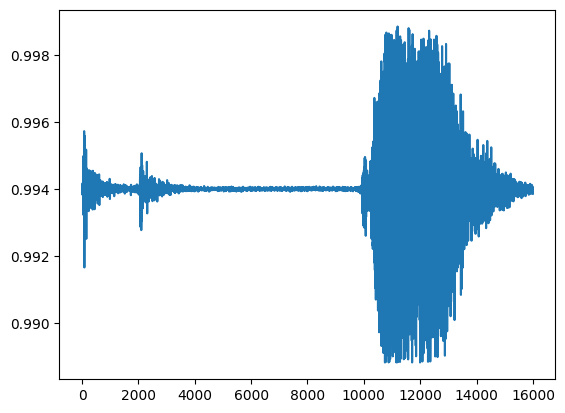

In [16]:
import matplotlib.pyplot as plt

plt.plot(dA[0, :, 10, 0])

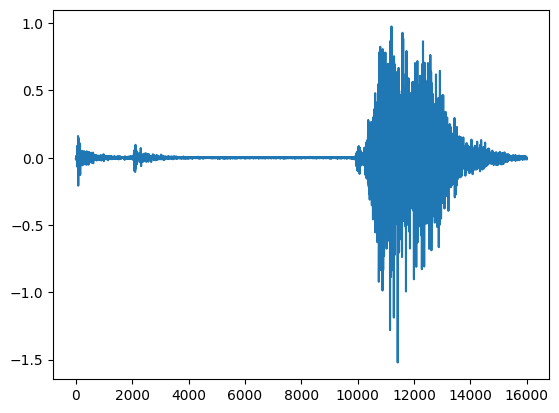

In [13]:
plt.plot(X[0].to('cpu'))

In [11]:
X[0].shape

torch.Size([16000, 1])